In [33]:
import cv2
import typing
import numpy as np

from mltu.inferenceModel import OnnxInferenceModel
from mltu.utils.text_utils import ctc_decoder, get_cer

In [34]:
class ImageToWordModel(OnnxInferenceModel):

    def __init__(self, char_list, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.char_list = char_list

    def predict(self, image):
    
        image = cv2.resize(image, (128, 32))
    
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
        image = image.astype(np.float32) / 255.0
    
        image = np.expand_dims(image, axis=0)
    
        preds = self.model.run(
            None,
            {self.input_name: image}
        )[0]
    
        print("Pred Shape:", preds.shape)
    
        # Get predicted indices
        pred_indices = np.argmax(preds, axis=2)[0]
    
        print("First 100 indices:")
        print(pred_indices[:100])
    
        print("Unique indices:")
        print(np.unique(pred_indices))
    
        text = ""
    
        last = -1
    
        for p in pred_indices:
    
            if p != last:
    
                # Ignore blank token
                if p < len(self.char_list):
                    text += self.char_list[p]
    
            last = p
    
        return text

In [35]:
print("Input Shape:", model.input_shape)
print("Input Name:", model.input_name)
print("Output Names:", model.output_names)

Input Shape: [32, 128, 3]
Input Name: input


AttributeError: 'ImageToWordModel' object has no attribute 'output_names'

In [36]:
print(np.argmax(preds[0], axis=1)[:30])

NameError: name 'preds' is not defined

In [37]:
prediction = model.predict(image)

print(prediction)

Input Shape: (1, 32, 128, 3)
n


In [25]:
if __name__ == "__main__":

    import os
    import cv2
    import numpy as np
    import pandas as pd

    from tqdm import tqdm
    from mltu.configs import BaseModelConfigs

    # -----------------------------
    # LOAD CONFIGS
    # -----------------------------
    configs = BaseModelConfigs.load(
        "../models/202211270035/configs.yaml"
    )

    # -----------------------------
    # FIX WRONG MODEL PATH
    # -----------------------------
    configs.model_path = "../models/202211270035/model.onnx"

    # -----------------------------
    # LOAD MODEL
    # -----------------------------
    model = ImageToWordModel(
        model_path=configs.model_path,
        char_list=configs.vocab
    )

    # -----------------------------
    # LOAD CSV
    # -----------------------------
    df = pd.read_csv(
        "../models/202211270035/val.csv"
    ).dropna().values.tolist()

    # -----------------------------
    # FILTER VALID FILES
    # -----------------------------
    valid_df = []

    for image_path, label in df:

        image_path = image_path.replace("\\", "/")

        # FIX DATASET PATH
        image_path = image_path.replace(
            "Datasets/90kDICT32px",
            "../datasets/mjsynth/mnt/ramdisk/max/90kDICT32px"
        )

        if os.path.exists(image_path):
            valid_df.append((image_path, label))

    print(f"\nTotal valid images: {len(valid_df)}")
    # -----------------------------
    # RUN INFERENCE
    # -----------------------------
    accum_cer = []

    for image_path, label in tqdm(valid_df[:20]):

        image = cv2.imread(image_path)

        if image is None:
            print(f"Failed to load: {image_path}")
            continue

        try:
            prediction_text = model.predict(image)

            cer = get_cer(prediction_text, label)

            print(
                f"\nImage: {image_path}\n"
                f"Label: {label}\n"
                f"Prediction: {prediction_text}\n"
                f"CER: {cer}\n"
            )

            accum_cer.append(cer)

        except Exception as e:
            print(f"Error processing {image_path}")
            print(e)

    # -----------------------------
    # FINAL METRIC
    # -----------------------------
    if len(accum_cer) > 0:
        print(f"\nAverage CER: {np.average(accum_cer)}")
    else:
        print("\nNo valid predictions were made.")


Total valid images: 802714


100%|█████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 382.92it/s]

Input Shape: (1, 32, 128, 3)

Image: ../datasets/mjsynth/mnt/ramdisk/max/90kDICT32px/2697/6/466_MONIKER_49537.jpg
Label: MONIKER
Prediction: n
CER: 1.0

Input Shape: (1, 32, 128, 3)

Image: ../datasets/mjsynth/mnt/ramdisk/max/90kDICT32px/2697/6/465_Ecclesiastics_24500.jpg
Label: Ecclesiastics
Prediction: n
CER: 1.0

Input Shape: (1, 32, 128, 3)

Image: ../datasets/mjsynth/mnt/ramdisk/max/90kDICT32px/2697/6/464_FIRESTORM_29099.jpg
Label: FIRESTORM
Prediction: n
CER: 1.0

Input Shape: (1, 32, 128, 3)

Image: ../datasets/mjsynth/mnt/ramdisk/max/90kDICT32px/2697/6/463_Psi_60982.jpg
Label: Psi
Prediction: n
CER: 1.0

Input Shape: (1, 32, 128, 3)

Image: ../datasets/mjsynth/mnt/ramdisk/max/90kDICT32px/2697/6/462_Repurchases_64997.jpg
Label: Repurchases
Prediction: n
CER: 1.0

Input Shape: (1, 32, 128, 3)

Image: ../datasets/mjsynth/mnt/ramdisk/max/90kDICT32px/2697/6/461_PIGTAIL_57575.jpg
Label: PIGTAIL
Prediction: n
CER: 1.0

Input Shape: (1, 32, 128, 3)

Image: ../datasets/mjsynth/mnt/ramdi

Input Shape: (1, 32, 128, 3)
Detected Text: n


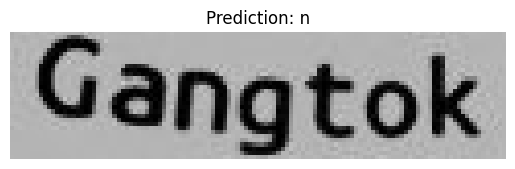

In [27]:
import cv2
import matplotlib.pyplot as plt

image_path = r"E:\Codes\Projects\Omni-Text\backend\ML\datasets\mjsynth\mnt\ramdisk\max\90kDICT32px\423\5\30_Gangtok_31698.jpg"   # put your image filename here

image = cv2.imread(image_path)

if image is None:
    print("Failed to load image")
else:

    prediction = model.predict(image)

    print(f"Detected Text: {prediction}")

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image_rgb)
    plt.title(f"Prediction: {prediction}")
    plt.axis("off")
    plt.show()